# Eigenschaften der CSV-Dateien filtern.
Ein paar Worte vorab:<br>
Bei der Filterung der Tabellen nach Äquivalenzrelationen sollte folgende vorab klargestellt werden, damit dies im Verlauf nicht zu Irritationen führen soll:<br>
Wenn zwei Dozenten/Lehrveranstaltungen unter einem Aspekt verglichen werden und dies in einer Äquivalenzrelationen wiedergegeben werden soll, so müssten zwar folgende Eigenschaften bei der (Teil-)Relation dargestellt werden:<br>
`    ` • Reflexivität "REF"<br>
`    ` • Symmetrie "SYM"<br>
`    ` • Transitivität "TRA"<br>
Im folgenden Code ist keine Funktion geben, was auf Reflexivität prüfen soll. Dieser Gedankengang wird zwar näher in der Arbeit erklärt (Verweise auf *"kommt noch"*).<br>
Der Grund kann grob folgendermaßen beschrieben werden, und zwar ist die Reflexivität im Kontext unserer Daten schon implizit enthalten, denn trotz fehlenden Einträgen in der Diagonalen, so wird gut wir er/sie selbst sein und die Antwortmöglicheten auf den Fragen bieten nichts anderes zu.

# Importe

In [1]:
import itertools
import matplotlib 
import multiprocessing as mp
import numpy as np
import pandas as pd
import random
import scipy
import sys

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx

from itertools import product, permutations
from multiprocessing import Pool, cpu_count
from scipy.optimize import dual_annealing


# Print versions of the libraries
print(f"Python version: {sys.version}\n")

print(f"Itertools module: Built-in, no version")
print(f"Multiprocessing module: Built-in, no version")
print(f"Random module: Built-in, no version\n")

print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scipy version: {scipy.__version__}")

Python version: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]

Itertools module: Built-in, no version
Multiprocessing module: Built-in, no version
Random module: Built-in, no version

Matplotlib version: 3.10.7
Numpy version: 2.0.2
Pandas version: 2.3.3
Scipy version: 1.14.1


## DataFrame laden

In [4]:
# Load the CSV file
file_path = 'Ergebnisse/LP_Verständlichkeit.csv'
df_orginal = pd.read_csv(file_path, header=None)

# Binäre Umwandlung (z.B., alle Werte > 0 zu 1, sonst 0)
df = (df_orginal > 0).astype(int)

# Selbe df spseter wichtig
df_binaer = (df_orginal > 0).astype(int)

for i in range(min(df.shape)):
    df.iat[i, i] = 1

# Display the first few rows of the matrix to understand its structure
df.head()

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
0,1,0,0,0,1,0,0,1,0,1,...,1,1,1,1,0,0,1,1,0,1
1,1,1,0,1,0,1,1,1,0,0,...,1,0,1,0,1,0,0,1,1,0
2,1,0,1,0,1,0,0,1,1,1,...,0,1,1,0,0,1,1,1,0,0
3,1,1,1,1,0,1,1,1,1,1,...,0,1,0,1,0,0,0,0,1,1
4,0,0,1,0,1,1,1,1,0,0,...,0,0,1,1,1,1,1,1,1,1


### Filterung der Teilmenge, die der Regel der Transitivität & Symmetrie folgen. Dies erfolgt mittels Prinzipien der "vectorize operations". (Vektoroperationen)
Das ist mir tatsächlich wegen einem Post in LinkedIn wieder eingefallen, denn zum einen wurde dies schon eins in der Vorlesung "Complexity, Randomisation, Aproximation and CAP-Learning" angesprochen und ist bei dem Datensatz "LP_Verständlichkeit" schneller gegenüber von multiprocessing.

### Funktionen

In [5]:
# Vektorisierte Symmetrieprüfung

def is_symmetric_vectorized(matrix) -> bool:
    return np.array_equal(matrix, matrix.T)

In [6]:
# Vektorisierte Transitivitätsprüfung

def is_transitive_vectorized(matrix, binaer:bool=True) -> bool:
    """
    Input:
    Return:
    """
    if binaer:
        # Stellt sicher, dass die Matrix boolesch interpretiert wird
        matrix = (matrix > 0).astype(int)
    
    # Berechne die quadratische Matrix
    matrix_squared = np.dot(matrix, matrix) > 0
    
    # Rückgabe und Überprüfen, ob alle Pfade aus matrix_squared auch in der ursprünglichen Matrix sind.
    return np.all((matrix_squared & (matrix == 0)) == False)

In [7]:
# Sliding Window zur Suche nach symmetrischen und transitiven Teilmatrizen

def find_symmetric_transitive_submatrices(matrix, min_size=2, max_size=10) -> np.array:
    """
    Findet alle quadratischen Teilmatrizen einer gegebenen Matrix, die sowohl symmetrisch 
    als auch transitiv sind.

    Durchsucht die gegebene Matrix nach allen möglichen Teilmatrizen mit einer Kantenlänge 
    zwischen `min_size` und `max_size`. Jede gefundene Teilmatrix wird auf Symmetrie und 
    Transitivität geprüft. Positionen aller gültigen Teilmatrizen werden zurückgegeben.

    Parameter
    ----------
    matrix : np.ndarray
        Eine quadratische Eingabematrix (2D NumPy-Array), die untersucht werden soll.
    min_size : int, optional
        Die minimale Größe der zu betrachtenden Teilmatrizen (Standard ist 2).
    max_size : int, optional
        Die maximale Größe der zu betrachtenden Teilmatrizen (Standard ist 10).

    Rückgabe
    --------
    list
        Eine Liste mit zwei Einträgen:
        - Eine Liste von Tupeln, die die Koordinaten der gültigen Teilmatrizen enthalten.
          Jedes Tupel besteht aus zwei weiteren Tupeln: ((start_row, end_row), (start_col, end_col)).
        - Die Gesamtanzahl der gefundenen symmetrisch-transitiven Teilmatrizen.
    """
    count = 0
    n = matrix.shape[0]
    symmetric_transitive_submatrices = []
    
    for size in range(min_size, min(max_size, n) + 1):
        for i in range(n - size + 1):
            for j in range(n - size + 1):
                submatrix = matrix[i:i+size, j:j+size]
                if is_symmetric_vectorized(submatrix) and is_transitive_vectorized(submatrix):
                    symmetric_transitive_submatrices.append(((i, i+size), (j, j+size)))
                    count += 1
                    
    return [symmetric_transitive_submatrices, count]

In [6]:
def objective_function(perm, matrix):
    """
    Bewertungsfunktion für simulated annealing.
    """
    perm = np.argsort(perm)
    permuted_matrix = matrix[np.ix_(perm, perm)]
    return find_symmetric_transitive_submatrices(permuted_matrix)

def optimize_permutation_simulated_annealing(matrix):
    """
    Optimiert die Permutation mit simulated annealing.
    """
    n = matrix.shape[0]
    bounds = [(0, n) for _ in range(n)]
    result = dual_annealing(objective_function, bounds, args=(matrix,))
    best_permutation = np.argsort(result.x)
    best_score = -result.fun
    return best_permutation, best_score

In [11]:
def evaluate_population(args):
    """
    Hilfsfunktion zur parallelen Bewertung der Population.
    """
    ind, matrix = args
    return objective_function(ind, matrix)[1]

def optimize_permutation_genetic_algorithm(matrix, population_size=50, generations=100, mutation_rate=0.1, num_workers=8):
    """
    Optimiert die Permutation mit einem genetischen Algorithmus und paralleler Bewertung.
    """
    n = matrix.shape[0]
    
    # Initiale Population erzeugen
    population = [np.random.permutation(n) for _ in range(population_size)]
    
    with Pool(num_workers) as pool:
        for generation in range(generations):
            # Fitness parallel berechnen
            scores = pool.map(evaluate_population, [(ind, matrix) for ind in population])
            sorted_indices = np.argsort(scores)[::-1]
            population = [population[i] for i in sorted_indices]
            
            # Selektion (Top 50%)
            num_selected = population_size // 2
            selected = population[:num_selected]
            
            # Crossover
            children = []
            while len(children) < population_size - num_selected:
                parent1, parent2 = random.sample(selected, 2)
                crossover_point = random.randint(0, n - 1)
                child = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
                # Stelle sicher, dass das Kind eine gültige Permutation ist
                _, idx = np.unique(child, return_index=True)
                missing = set(range(n)) - set(child)
                for i in range(n):
                    if i not in idx:
                        child[i] = missing.pop()
                children.append(child)
            
            # Mutation
            for child in children:
                if random.random() < mutation_rate:
                    i, j = random.sample(range(n), 2)
                    child[i], child[j] = child[j], child[i]
            
            population = selected + children
    
    # Beste Lösung zurückgeben
    best_permutation = population[0]
    best_score = objective_function(best_permutation, matrix)
    return best_permutation, best_score

In [12]:
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
matrix_np = df.to_numpy()

best_perm, best_score = optimize_permutation_genetic_algorithm(matrix=matrix_np, generations=10)
print("Beste Permutation:", best_perm)
print("Beste Punktzahl:", best_score)

Beste Permutation: [ 56  90  65  23  64  39  44  10  40  36  43  62  94  67  31  33  32  80
  73  29  84  49  60   7 104   5  68  50  42  57 102  12  51  88   4  76
  93 100   1  26  79  53   9   3  66  25  55 105  75  14  37 101  18  59
  46  48  58  52   6  38  24  54  98  16  97  35  81  96  11  15  21  13
  47  41   0   2  17  34  99  70  71   8 103  82  72  69  86  45  87  78
  20  91  92  74  22  19  83  89  27  28  61  85  30  77  63  95]
Beste Punktzahl: [[((0, 2), (0, 2)), ((0, 2), (2, 4)), ((0, 2), (4, 6)), ((0, 2), (6, 8)), ((0, 2), (14, 16)), ((0, 2), (19, 21)), ((0, 2), (25, 27)), ((0, 2), (27, 29)), ((0, 2), (31, 33)), ((0, 2), (37, 39)), ((0, 2), (39, 41)), ((0, 2), (40, 42)), ((0, 2), (41, 43)), ((0, 2), (42, 44)), ((0, 2), (48, 50)), ((0, 2), (50, 52)), ((0, 2), (53, 55)), ((0, 2), (56, 58)), ((0, 2), (62, 64)), ((0, 2), (65, 67)), ((0, 2), (69, 71)), ((0, 2), (72, 74)), ((0, 2), (77, 79)), ((0, 2), (79, 81)), ((0, 2), (80, 82)), ((0, 2), (81, 83)), ((0, 2), (83, 85)),

In [55]:
print(type(best_perm))
print(type(matrix_np))

# DataFrame nach bester Permutation sortieren
df_sorted = df.iloc[best_perm, :].iloc[:, best_perm]
print("Sortiertes DataFrame:")
print(df_sorted)
matrix_np = df_sorted.to_numpy()

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Sortiertes DataFrame:
    56  90  65  23  64  39  44  10  40  36  ...  83  89  27  28  61  85  30  \
56   1   0   1   0   1   0   0   1   1   1  ...   1   0   0   1   1   0   0   
90   1   1   1   1   1   0   0   1   0   1  ...   0   1   1   1   0   0   1   
65   1   1   1   0   1   0   1   1   1   0  ...   0   0   1   1   0   1   1   
23   1   0   0   1   0   0   1   0   0   1  ...   1   0   0   1   0   1   0   
64   1   1   0   0   1   0   0   0   1   0  ...   0   1   1   0   0   0   1   
..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..  ..  ..  ..   
85   0   0   1   1   1   1   0   0   1   0  ...   1   1   0   1   1   1   0   
30   0   1   1   0   1   0   1   0   1   1  ...   1   1   1   0   0   1   1   
77   1   1   0   0   0   0   1   1   0   0  ...   1   1   1   0   1   1   1   
63   0   1   0   1   0   0   1   0   1   1  ...   1   1   0   1   0   1   0   
95   0   0   0   1   1   1   1   0   1   1  ...   1   0   1  

### Anwendung

In [9]:
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
matrix_np = df.to_numpy()

# Finde symmetrische und transitive Teilmatrizen mit vektorisierten Operationen (bis Größe m, also so groß wie die Matrix selbst, jedoch kam es nicht zu Ordnungen über die 10)
symmetric_transitive_submatrices_vec = find_symmetric_transitive_submatrices(matrix_np, min_size=2, max_size=df.shape[1])[0]

# Ausgabe der ersten 5 gefundenen Bereiche
print(f"Die ersten 5 symmetrischen und transtiven Matrizen:\n{symmetric_transitive_submatrices_vec[:5]}")

Die ersten 5 symmetrischen und transtiven Matrizen:
[((0, 2), (2, 4)), ((0, 2), (4, 6)), ((0, 2), (12, 14)), ((0, 2), (17, 19)), ((0, 2), (19, 21))]


============================================================================================================================================================================================================================================================================================================
### Es folgt eine Aussortierung der Matrizen, die sich nicht an der Diagonalen befinden, da die geschriebene Funktion zwar bei übergebene Matrizen die Eigenschaften TRA und SYM richtig findet, aber bei Teilmatrizen die Symmetrie (wegen der eigenen Regel) nur dann garanitert werden kann, wenn wenn es sich an der Diagonale befindet.
Die größtmöglichen Quadrate an der Diagonale zu finden, ist dowieso das Ziel um Äquivalenzklassen bilden zu können.

In [57]:
# Filtere symmetrische und transitive Teilmatrizen mit denselben Zeilen- und Spaltennummern
symmetric_transitive_same_rows_cols = [
    (rows, cols) for rows, cols in symmetric_transitive_submatrices_vec if rows == cols
]

# Ausgabe der ersten 5 gefundenen Bereiche, die an der Hauptdiagonalen sind
print(f"Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:\n{symmetric_transitive_same_rows_cols[:5]}")

Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:
[((1, 3), (1, 3)), ((2, 4), (2, 4)), ((3, 5), (3, 5)), ((5, 7), (5, 7)), ((6, 8), (6, 8))]


In [58]:
# Konvertiere die DataFrame-Matrix in ein NumPy-Array für vektorisierte Operationen
binaer_matrix_np = df_binaer.to_numpy()

# Finde symmetrische und transitive Teilmatrizen mit vektorisierten Operationen (bis Größe 10)
binaer_symmetric_transitive_submatrices_vec = find_symmetric_transitive_submatrices(binaer_matrix_np, min_size=2, max_size=df.shape[1])[0]

# Ausgabe der ersten 5 gefundenen Bereiche
print(f"Wieder die ersten 5 symmetrischen und transtiven Matrizen bei binärer Matrix:\n{binaer_symmetric_transitive_submatrices_vec[:5]}")

Wieder die ersten 5 symmetrischen und transtiven Matrizen bei binärer Matrix:
[((0, 2), (1, 3)), ((0, 2), (2, 4)), ((0, 2), (4, 6)), ((0, 2), (12, 14)), ((0, 2), (17, 19))]


In [59]:
# Filtere symmetrische und transitive Teilmatrizen mit denselben Zeilen- und Spaltennummern
binaer_symmetric_transitive_same_rows_cols = [
    (rows, cols) for rows, cols in binaer_symmetric_transitive_submatrices_vec if rows == cols
]

# Ausgabe der ersten 5 gefundenen Bereiche, die an der Hauptdiagonalen sind
print(f"Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:\n{binaer_symmetric_transitive_same_rows_cols[:5]}")

Die ersten 5 symmetrischen und transtiven Matrizen, die an der Diagonalen verlaufen:
[((1, 3), (1, 3)), ((3, 5), (3, 5)), ((21, 23), (21, 23)), ((25, 27), (25, 27)), ((27, 29), (27, 29))]


In [60]:
"""
length=len(end_list)
for l in range(length):
    print(df_orginal.iloc[end_list[l][0][0]:end_list[l][0][1], end_list[l][0][0]:end_list[l][0][1]], "\n")

print(df_orginal.iloc[94:97, 94:97])
"""
end_list=list(set(binaer_symmetric_transitive_same_rows_cols) - set(symmetric_transitive_same_rows_cols))
print(end_list, "\n")

end_list=list(set(symmetric_transitive_same_rows_cols) - set(binaer_symmetric_transitive_same_rows_cols))
print(end_list)

[((80, 82), (80, 82)), ((45, 47), (45, 47)), ((67, 69), (67, 69)), ((21, 23), (21, 23)), ((51, 53), (51, 53)), ((83, 85), (83, 85)), ((25, 27), (25, 27)), ((77, 79), (77, 79)), ((63, 65), (63, 65)), ((99, 101), (99, 101))] 

[((57, 59), (57, 59)), ((75, 78), (75, 78)), ((14, 16), (14, 16)), ((35, 38), (35, 38)), ((12, 14), (12, 14)), ((22, 24), (22, 24)), ((98, 100), (98, 100)), ((87, 89), (87, 89)), ((20, 22), (20, 22)), ((64, 66), (64, 66)), ((5, 7), (5, 7)), ((60, 63), (60, 63)), ((91, 94), (91, 94)), ((36, 38), (36, 38)), ((86, 88), (86, 88)), ((44, 46), (44, 46)), ((56, 58), (56, 58)), ((97, 99), (97, 99)), ((16, 18), (16, 18)), ((93, 96), (93, 96)), ((84, 86), (84, 86)), ((59, 61), (59, 61)), ((92, 94), (92, 94)), ((10, 12), (10, 12)), ((100, 102), (100, 102)), ((18, 20), (18, 20)), ((41, 43), (41, 43)), ((61, 63), (61, 63)), ((69, 71), (69, 71)), ((49, 51), (49, 51)), ((60, 62), (60, 62)), ((94, 96), (94, 96)), ((72, 74), (72, 74)), ((75, 77), (75, 77)), ((32, 34), (32, 34)), ((

In [61]:
# Array für die gesammelten DataFrame-Ausschnitte
intervalle = []

length=len(end_list)

# Schleife zum Sammeln der Ausschnitte
for l in range(length):
    intervalle.append(end_list[l][0])

# Optional: In ein NumPy-Array konvertieren, falls einheitliche Form
# intervalle = np.array(intervalle, dtype=object)
intervalle

[(57, 59),
 (75, 78),
 (14, 16),
 (35, 38),
 (12, 14),
 (22, 24),
 (98, 100),
 (87, 89),
 (20, 22),
 (64, 66),
 (5, 7),
 (60, 63),
 (91, 94),
 (36, 38),
 (86, 88),
 (44, 46),
 (56, 58),
 (97, 99),
 (16, 18),
 (93, 96),
 (84, 86),
 (59, 61),
 (92, 94),
 (10, 12),
 (100, 102),
 (18, 20),
 (41, 43),
 (61, 63),
 (69, 71),
 (49, 51),
 (60, 62),
 (94, 96),
 (72, 74),
 (75, 77),
 (32, 34),
 (35, 37),
 (2, 4),
 (52, 54),
 (88, 90),
 (22, 25),
 (23, 25),
 (79, 81),
 (38, 40),
 (6, 8),
 (9, 11),
 (85, 87),
 (76, 78)]

In [62]:
# Array für die gesammelten DataFrame-Ausschnitte
intervalle = []

length=len(end_list)

# Schleife zum Sammeln der Ausschnitte
for l in range(length):
    intervalle.append(end_list[l][0])

# Optional: In ein NumPy-Array konvertieren, falls einheitliche Form
# intervalle = np.array(intervalle, dtype=object)
intervalle

# Hilfsfunktion zum Überprüfen von Überlappungen
def ueberlappen(interval1, interval2):
    return interval1[1] >= interval2[0] and interval2[1] >= interval1[0]

# Äquivalenzklassen erstellen
def bilde_aequivalenzklassen(intervalle):
    intervalle = sorted(intervalle)
    klassen = []

    while intervalle:
        aktuelle_klasse = [intervalle.pop(0)]
        i = 0

        while i < len(intervalle):
            if any(ueberlappen(interval, intervalle[i]) for interval in aktuelle_klasse):
                aktuelle_klasse.append(intervalle.pop(i))
            else:
                i += 1

        klassen.append(aktuelle_klasse)

    return klassen

# Äquivalenzklassen berechnen
aequivalenzklassen = bilde_aequivalenzklassen(intervalle)

# Ausgabe als DataFrame für Übersicht
df_aequivalenzklassen = pd.DataFrame({'Äquivalenzklasse': range(1, len(aequivalenzklassen)+1), 'Intervalle': aequivalenzklassen})

print(df_aequivalenzklassen)

    Äquivalenzklasse                                         Intervalle
0                  1                                           [(2, 4)]
1                  2                                   [(5, 7), (6, 8)]
2                  3  [(9, 11), (10, 12), (12, 14), (14, 16), (16, 1...
3                  4                                         [(32, 34)]
4                  5           [(35, 37), (35, 38), (36, 38), (38, 40)]
5                  6                                         [(41, 43)]
6                  7                                         [(44, 46)]
7                  8                                         [(49, 51)]
8                  9                                         [(52, 54)]
9                 10  [(56, 58), (57, 59), (59, 61), (60, 62), (60, ...
10                11                                         [(64, 66)]
11                12                                         [(69, 71)]
12                13                                         [(7

In [63]:
print(df_aequivalenzklassen['Intervalle'][0])

[(2, 4)]


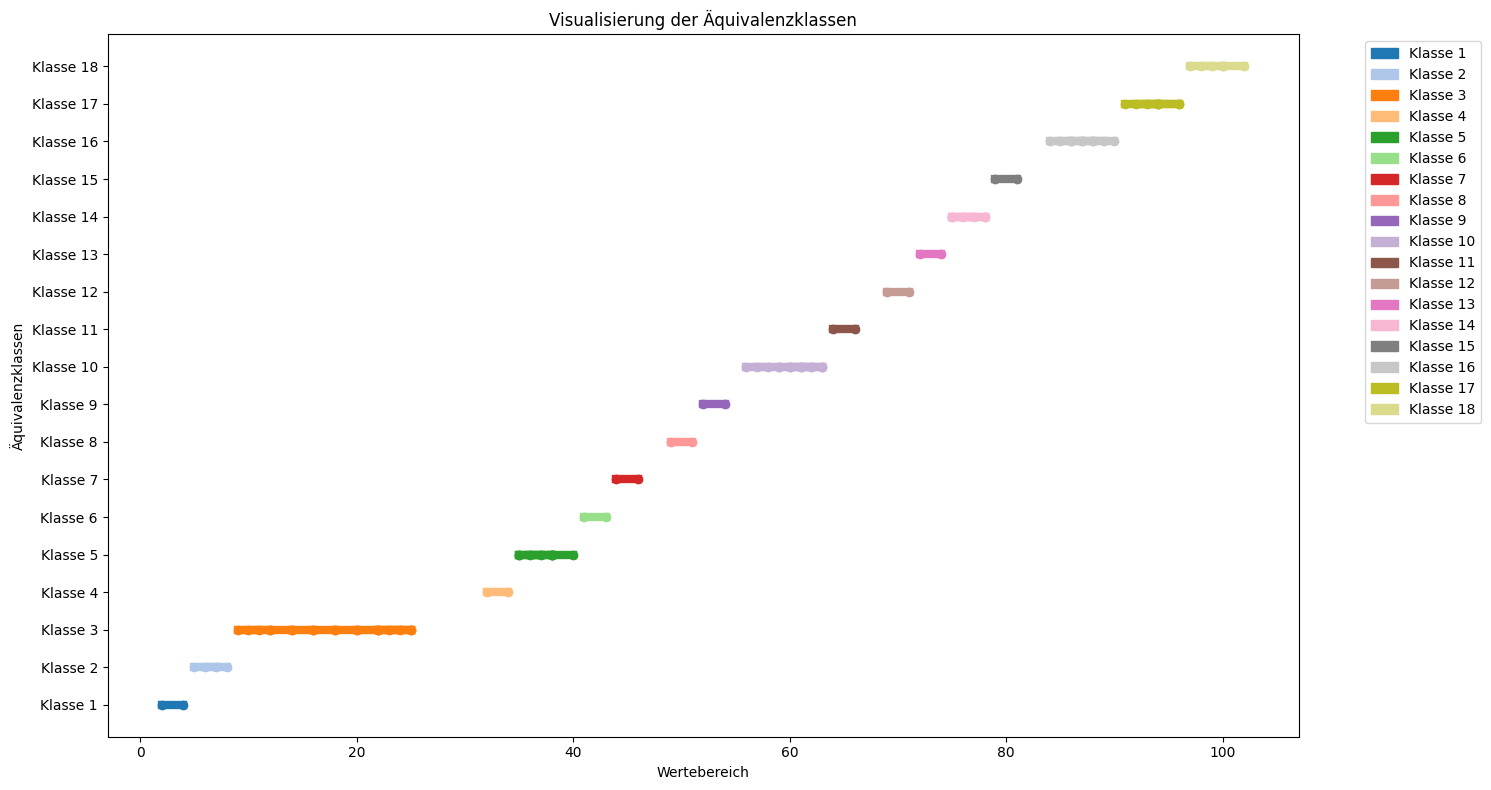

In [64]:
# Visualisierung der Äquivalenzklassen als Balkendiagramm

# Farben für verschiedene Äquivalenzklassen
farben = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(15, 8))

# Plot der Intervalle für jede Äquivalenzklasse
for i, klasse in enumerate(aequivalenzklassen):
    for interval in klasse:
        ax.plot([interval[0], interval[1]], [i, i], marker='o', linewidth=6, color=farben[i % len(farben)])

# Achsentitel und Beschriftungen
ax.set_yticks(range(len(aequivalenzklassen)))
ax.set_yticklabels([f'Klasse {i+1}' for i in range(len(aequivalenzklassen))])
ax.set_xlabel('Wertebereich')
ax.set_ylabel('Äquivalenzklassen')
ax.set_title('Visualisierung der Äquivalenzklassen')

# Legende hinzufügen
legenden_patches = [mpatches.Patch(color=farben[i % len(farben)], label=f'Klasse {i+1}') for i in range(len(aequivalenzklassen))]
ax.legend(handles=legenden_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

    Äquivalenzklasse                                         Intervalle
0                  1                                           [(2, 4)]
1                  2                                   [(5, 7), (6, 8)]
2                  3  [(9, 11), (10, 12), (12, 14), (14, 16), (16, 1...
3                  4                                         [(32, 34)]
4                  5           [(35, 37), (35, 38), (36, 38), (38, 40)]
5                  6                                         [(41, 43)]
6                  7                                         [(44, 46)]
7                  8                                         [(49, 51)]
8                  9                                         [(52, 54)]
9                 10  [(56, 58), (57, 59), (59, 61), (60, 62), (60, ...
10                11                                         [(64, 66)]
11                12                                         [(69, 71)]
12                13                                         [(7

IndexError: list index out of range

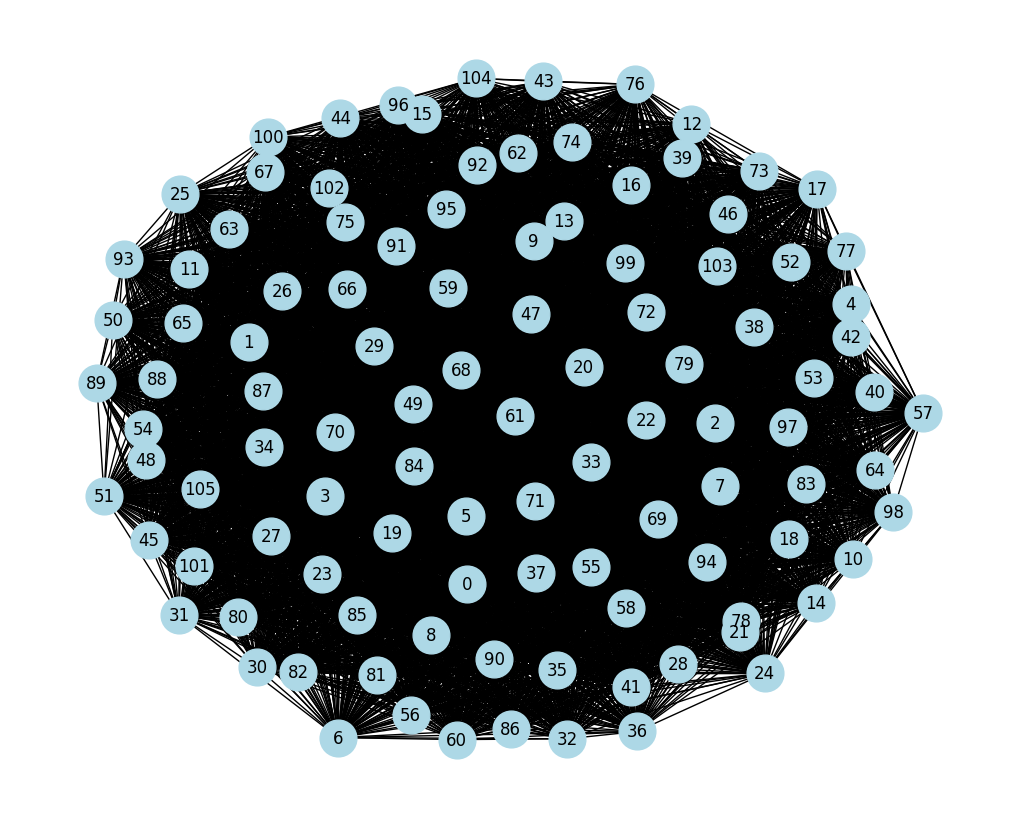

In [65]:
# Äquivalenzklassen bestimmen
visited = set()
clusters = []

def dfs(node, cluster):
    for neighbor in range(len(matrix_np)):
        if matrix_np[node, neighbor] == 1 and neighbor not in visited:
            visited.add(neighbor)
            cluster.append(neighbor)
            dfs(neighbor, cluster)

for node in range(len(matrix_np)):
    if node not in visited:
        cluster = [node]
        visited.add(node)
        dfs(node, cluster)
        clusters.append(cluster)

# Ausgabe anzeigen
print(df_aequivalenzklassen)

# Graph erstellen
graph = nx.Graph()

# Knoten und Kanten hinzufügen
for i, cluster in enumerate(clusters):
    for node in cluster:
        graph.add_node(node, label=f"{cluster[node]}")
        for neighbor in cluster:
            if node != neighbor:
                graph.add_edge(node, neighbor)

# Graph zeichnen
pos = nx.spring_layout(graph)  # Layout für Graph-Positionierung
plt.figure(figsize=(10, 8))
nx.draw(graph, pos, with_labels=True, node_size=700, node_color="lightblue")
labels = {node: str(intervalle[node]) for node in graph.nodes}
nx.draw_networkx_labels(graph, pos, labels=labels)
plt.title("Graphische Darstellung der Äquivalenzklassen")
plt.show()


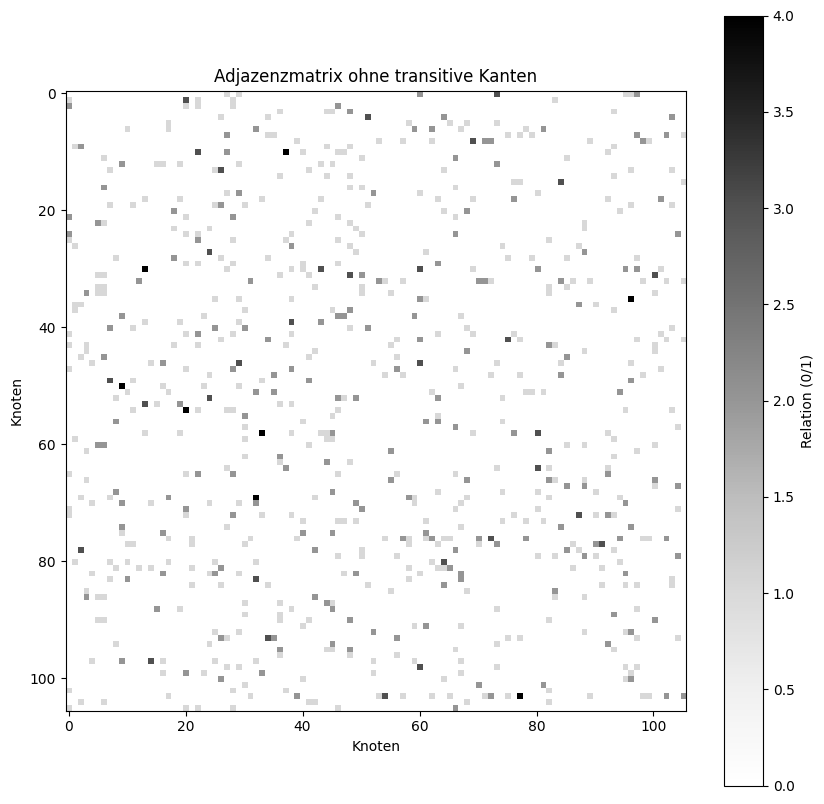

In [66]:
# Convert the dataframe to a numpy array
matrix_np = df_orginal.to_numpy()

# Function to remove transitive edges
def remove_transitive_edges(matrix):
    n = matrix.shape[0]
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if matrix[i, k] and matrix[k, j] and i != j:
                    matrix[i, j] = 0
    return matrix

# Remove transitive edges from the matrix
matrix_no_transitive = remove_transitive_edges(matrix_np.copy())

# Plot the resulting matrix
plt.figure(figsize=(10, 10))
plt.imshow(matrix_no_transitive, cmap='Greys', interpolation='none')
plt.title('Adjazenzmatrix ohne transitive Kanten')
plt.colorbar(label='Relation (0/1)')
plt.xlabel('Knoten')
plt.ylabel('Knoten')
plt.show()

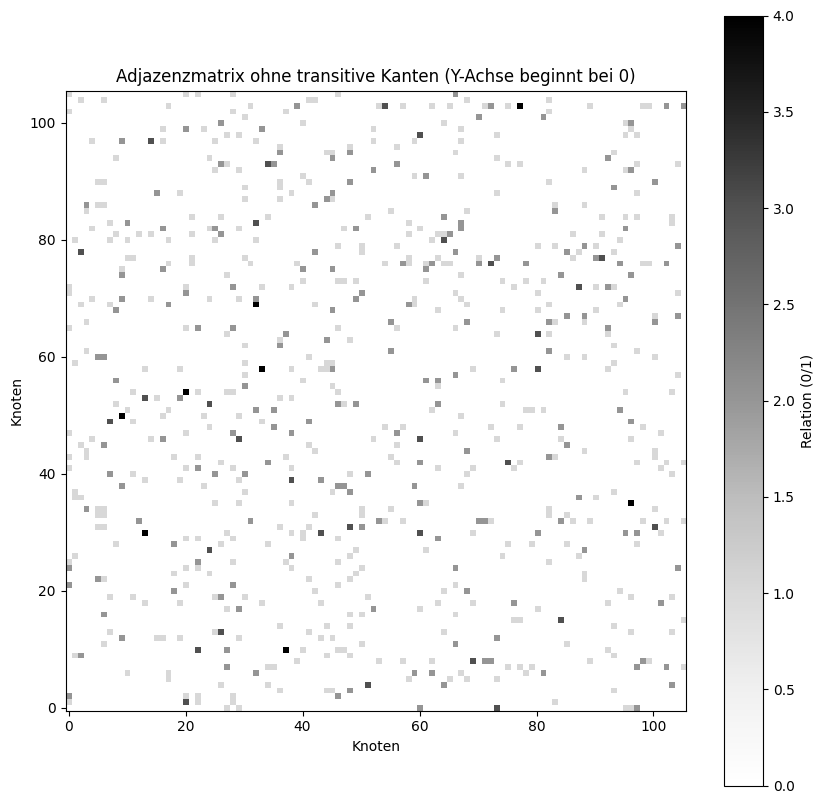

In [67]:
# Plot the matrix with the y-axis starting at 0 (inverted y-axis)
plt.figure(figsize=(10, 10))
plt.imshow(matrix_no_transitive, cmap='Greys', interpolation='none')
plt.title('Adjazenzmatrix ohne transitive Kanten (Y-Achse beginnt bei 0)')
plt.colorbar(label='Relation (0/1)')
plt.xlabel('Knoten')
plt.ylabel('Knoten')
plt.gca().invert_yaxis()  # Start y-axis from 0 at the bottom
plt.show()

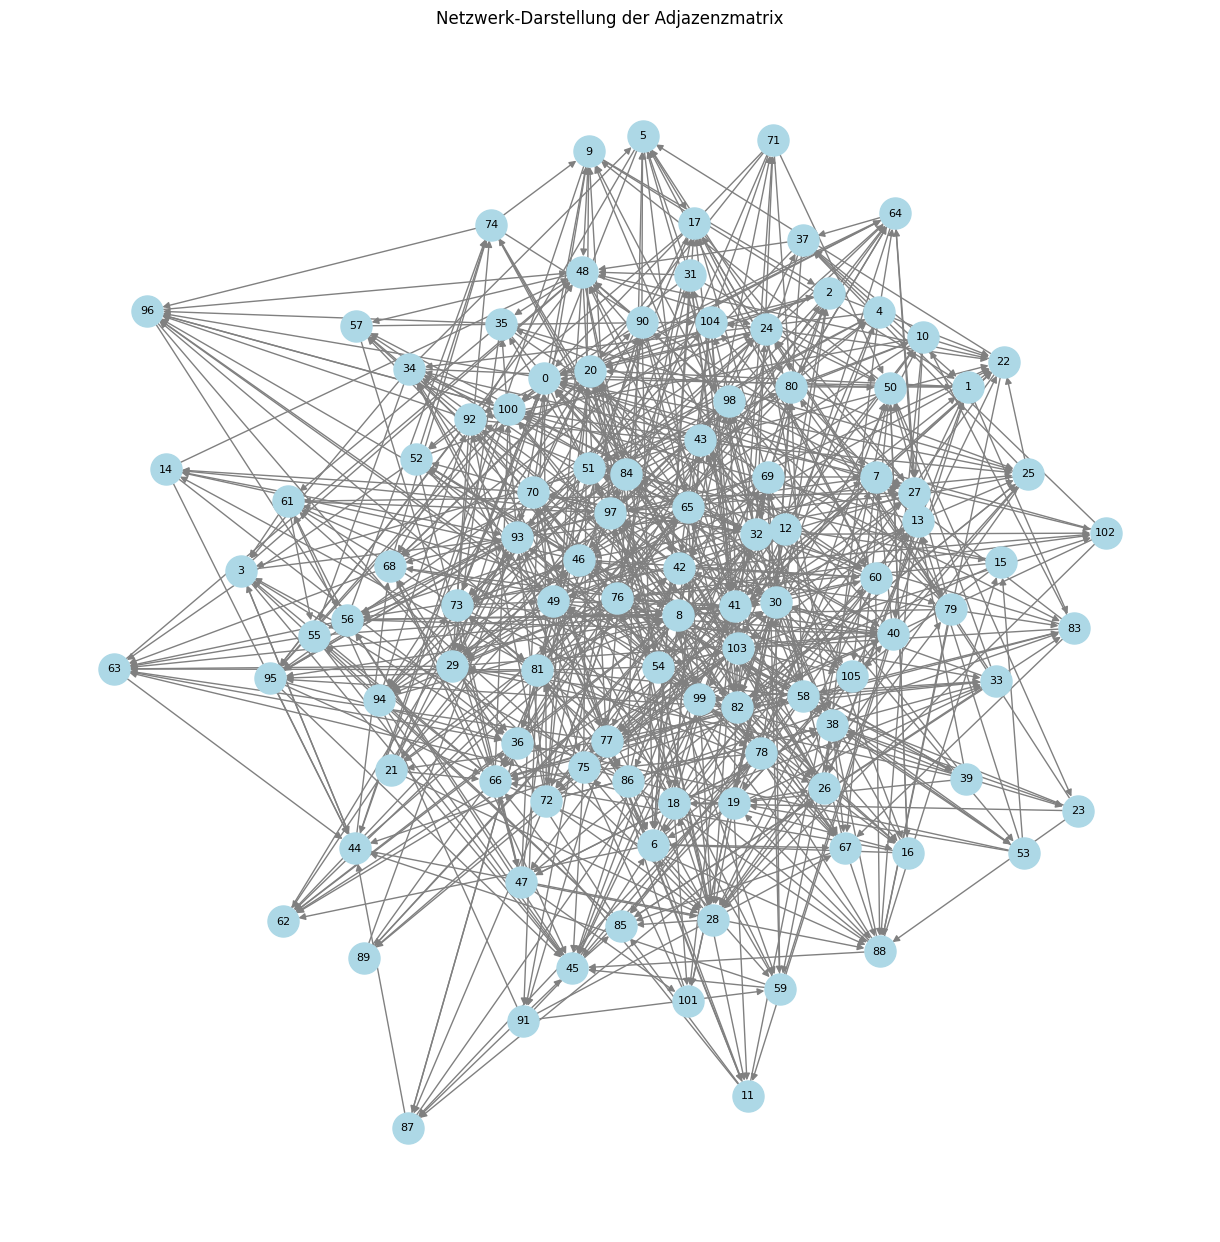

In [68]:
# Create a NetworkX graph from the adjacency matrix
G = nx.from_numpy_array(matrix_no_transitive, create_using=nx.DiGraph)

# Plot the graph using a spring layout
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Fruchterman-Reingold layout
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=500,
    font_size=8,
    edge_color="gray",
    arrowsize=10,
)
plt.title("Netzwerk-Darstellung der Adjazenzmatrix")
plt.show()

In [69]:
import pandas as pd

# Funktion zur Zusammenführung der Intervalle und Generierung der Bezeichnung
def merge_intervals_and_label(row):
    merged_intervals = []
    for interval in sorted(row['Intervalle']):
        if not merged_intervals or interval[0] > merged_intervals[-1][1]:
            merged_intervals.append(interval)
        else:
            merged_intervals[-1] = (merged_intervals[-1][0], max(merged_intervals[-1][1], interval[1]))
    label = f"Äquivalenzklasse{row['Äquivalenzklasse']}"
    return {"Label": label, "Intervalle": merged_intervals}

# Zusammenführen und Beschriften
result = df_aequivalenzklassen.apply(merge_intervals_and_label, axis=1)

# Konvertiere das Ergebnis in ein DataFrame
merged_df = pd.DataFrame(result.tolist())

# Anzeigen des Ergebnisses
#import ace_tools as tools; tools.display_dataframe_to_user(name="Zusammengeführte Äquivalenzklassen", dataframe=merged_df)

display(merged_df)


,Label,Intervalle
0,Äquivalenzklasse1,"[(2, 4)]"
1,Äquivalenzklasse2,"[(5, 8)]"
2,Äquivalenzklasse3,"[(9, 25)]"
3,Äquivalenzklasse4,"[(32, 34)]"
4,Äquivalenzklasse5,"[(35, 40)]"
5,Äquivalenzklasse6,"[(41, 43)]"
6,Äquivalenzklasse7,"[(44, 46)]"
7,Äquivalenzklasse8,"[(49, 51)]"
8,Äquivalenzklasse9,"[(52, 54)]"
9,Äquivalenzklasse10,"[(56, 63)]"


In [70]:
# Create a mapping of nodes to equivalence classes
node_to_class = {}
for aequiv_class, interval in aequivalenzklassen.items():
    for node in interval:
        node_to_class[node] = aequiv_class

# Assign a color to each equivalence class for visualization
class_colors = {1: "lightblue", 2: "lightgreen"}
node_colors = [class_colors.get(node_to_class.get(node, 0), "gray") for node in G.nodes]

# Plot the graph with equivalence class coloring
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=500,
    font_size=8,
    edge_color="gray",
    arrowsize=10,
)
plt.title("Netzwerk-Darstellung mit Äquivalenzklassen")
plt.show()

TypeError: unhashable type: 'list'

    Äquivalenzklasse                                         Intervalle
0                  1  [[(2, 4)], [(5, 7), (6, 8)], [(9, 11), (10, 12...
1                  2  [[(35, 37), (35, 38), (36, 38), (38, 40)], [(4...
2                  3                                       [[(49, 51)]]
3                  4                                       [[(52, 54)]]
4                  5  [[(56, 58), (57, 59), (59, 61), (60, 62), (60,...
5                  6                                       [[(64, 66)]]
6                  7                                       [[(69, 71)]]
7                  8                                       [[(72, 74)]]
8                  9                   [[(75, 77), (75, 78), (76, 78)]]
9                 10                                       [[(79, 81)]]
10                11  [[(84, 86), (85, 87), (86, 88), (87, 89), (88,...
11                12         [[(91, 94), (92, 94), (93, 96), (94, 96)]]
12                13                [[(97, 99), (98, 100), (100,

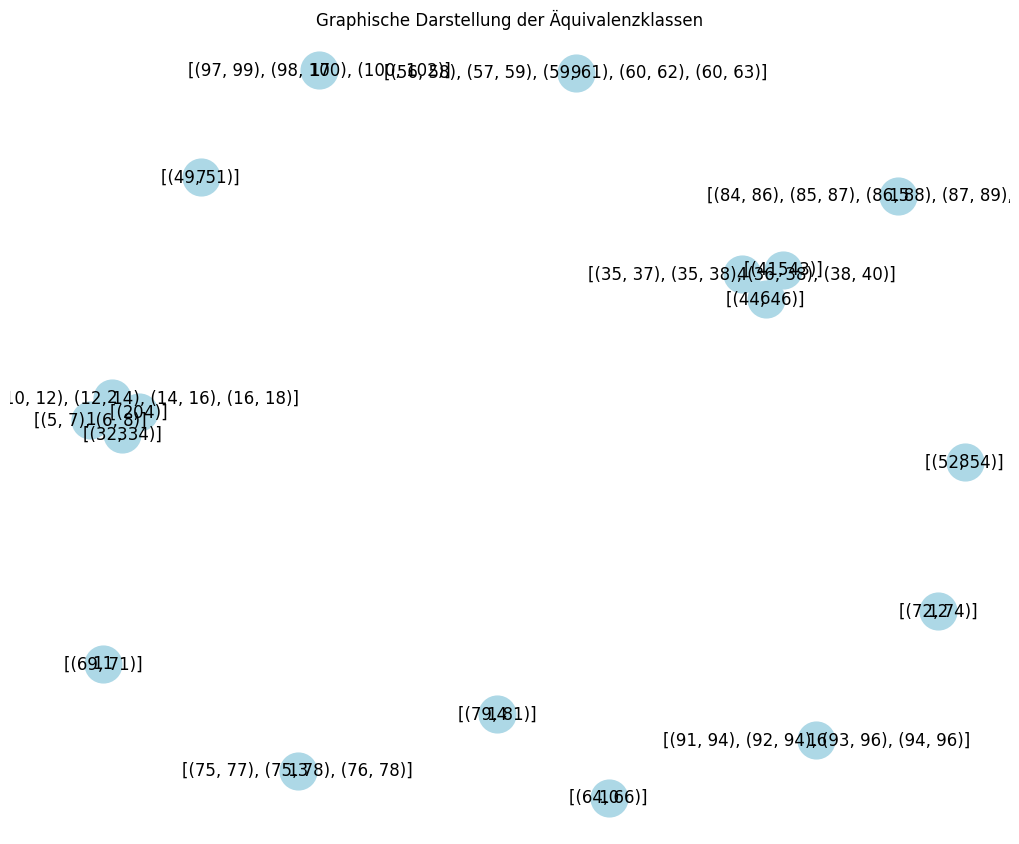

In [34]:
# Beispiel-Matrix (Relation zwischen Intervallen)
m = 18  # Anzahl Intervalle
relation_matrix = np.zeros((m, m))  # Beispiel: leere m*m-Matrix

# Populiere die Matrix mit Beispielwerten (1 für Relation, 0 für keine Relation)
# Beispiel-Daten einfügen (manuell oder automatisch generiert)
relation_matrix[0, 1] = 1
relation_matrix[1, 2] = 1
relation_matrix[2, 3] = 1
relation_matrix[4, 5] = 1
relation_matrix[5, 6] = 1
relation_matrix[6, 4] = 1  # Zyklus
# (weitere Verbindungen hinzufügen)

# Symmetrische Matrix für bidirektionale Relation
temp = relation_matrix + relation_matrix.T
relation_matrix = np.where(temp > 0, 1, 0)

# Liste der Intervalle aus dem DataFrame extrahieren
intervalle = [
    [(2, 4)],
    [(5, 7), (6, 8)],
    [(9, 11), (10, 12), (12, 14), (14, 16), (16, 18)],
    [(32, 34)],
    [(35, 37), (35, 38), (36, 38), (38, 40)],
    [(41, 43)],
    [(44, 46)],
    [(49, 51)],
    [(52, 54)],
    [(56, 58), (57, 59), (59, 61), (60, 62), (60, 63)],
    [(64, 66)],
    [(69, 71)],
    [(72, 74)],
    [(75, 77), (75, 78), (76, 78)],
    [(79, 81)],
    [(84, 86), (85, 87), (86, 88), (87, 89), (88, 90)],
    [(91, 94), (92, 94), (93, 96), (94, 96)],
    [(97, 99), (98, 100), (100, 102)]
]

# Äquivalenzklassen bestimmen
visited = set()
clusters = []

def dfs(node, cluster):
    for neighbor in range(len(relation_matrix)):
        if relation_matrix[node, neighbor] == 1 and neighbor not in visited:
            visited.add(neighbor)
            cluster.append(neighbor)
            dfs(neighbor, cluster)

for node in range(len(relation_matrix)):
    if node not in visited:
        cluster = [node]
        visited.add(node)
        dfs(node, cluster)
        clusters.append(cluster)

# Äquivalenzklassen zu DataFrame
df_aequivalenzklassen = pd.DataFrame({
    'Äquivalenzklasse': range(1, len(clusters) + 1),
    'Intervalle': [[intervalle[i] for i in cluster] for cluster in clusters]
})

# Ausgabe anzeigen
print(df_aequivalenzklassen)

# Graph erstellen
graph = nx.Graph()

# Knoten und Kanten hinzufügen
for i, cluster in enumerate(clusters):
    for node in cluster:
        graph.add_node(node, label=f"{intervalle[node]}")
        for neighbor in cluster:
            if node != neighbor:
                graph.add_edge(node, neighbor)

# Graph zeichnen
pos = nx.spring_layout(graph)  # Layout für Graph-Positionierung
plt.figure(figsize=(10, 8))
nx.draw(graph, pos, with_labels=True, node_size=700, node_color="lightblue")
labels = {node: str(intervalle[node]) for node in graph.nodes}
nx.draw_networkx_labels(graph, pos, labels=labels)
plt.title("Graphische Darstellung der Äquivalenzklassen")
plt.show()

### Best mögliche Permutation der Anordnung der Dozenten/Lehrveranstaltung

In [26]:
end_list=list(
    set(symmetric_transitive_submatrices_vec) - set(binaer_symmetric_transitive_submatrices_vec)
)
end_list[:5]

[((47, 49), (9, 11)),
 ((53, 55), (18, 20)),
 ((91, 94), (30, 33)),
 ((29, 31), (37, 39)),
 ((95, 97), (25, 27))]

In [27]:
# Array für die gesammelten DataFrame-Ausschnitte
intervalle = []

length=len(end_list)

# Schleife zum Sammeln der Ausschnitte
for l in range(length):
    intervalle.append(end_list[l][0])


# Hilfsfunktion zum Überprüfen von Überlappungen
def ueberlappen(interval1, interval2):
    return interval1[1] >= interval2[0] and interval2[1] >= interval1[0]

# Äquivalenzklassen erstellen
def bilde_aequivalenzklassen(intervalle):
    intervalle = sorted(intervalle)
    klassen = []

    while intervalle:
        aktuelle_klasse = [intervalle.pop(0)]
        i = 0

        while i < len(intervalle):
            if any(ueberlappen(interval, intervalle[i]) for interval in aktuelle_klasse):
                aktuelle_klasse.append(intervalle.pop(i))
            else:
                i += 1

        klassen.append(aktuelle_klasse)

    return klassen

# Äquivalenzklassen berechnen
aequivalenzklassen = bilde_aequivalenzklassen(intervalle)

# Ausgabe als DataFrame für Übersicht
df_aequivalenzklassen = pd.DataFrame({'Äquivalenzklasse': range(1, len(aequivalenzklassen)+1), 'Intervalle': aequivalenzklassen})

print(df_aequivalenzklassen)

   Äquivalenzklasse                                         Intervalle
0                 1  [(0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2...


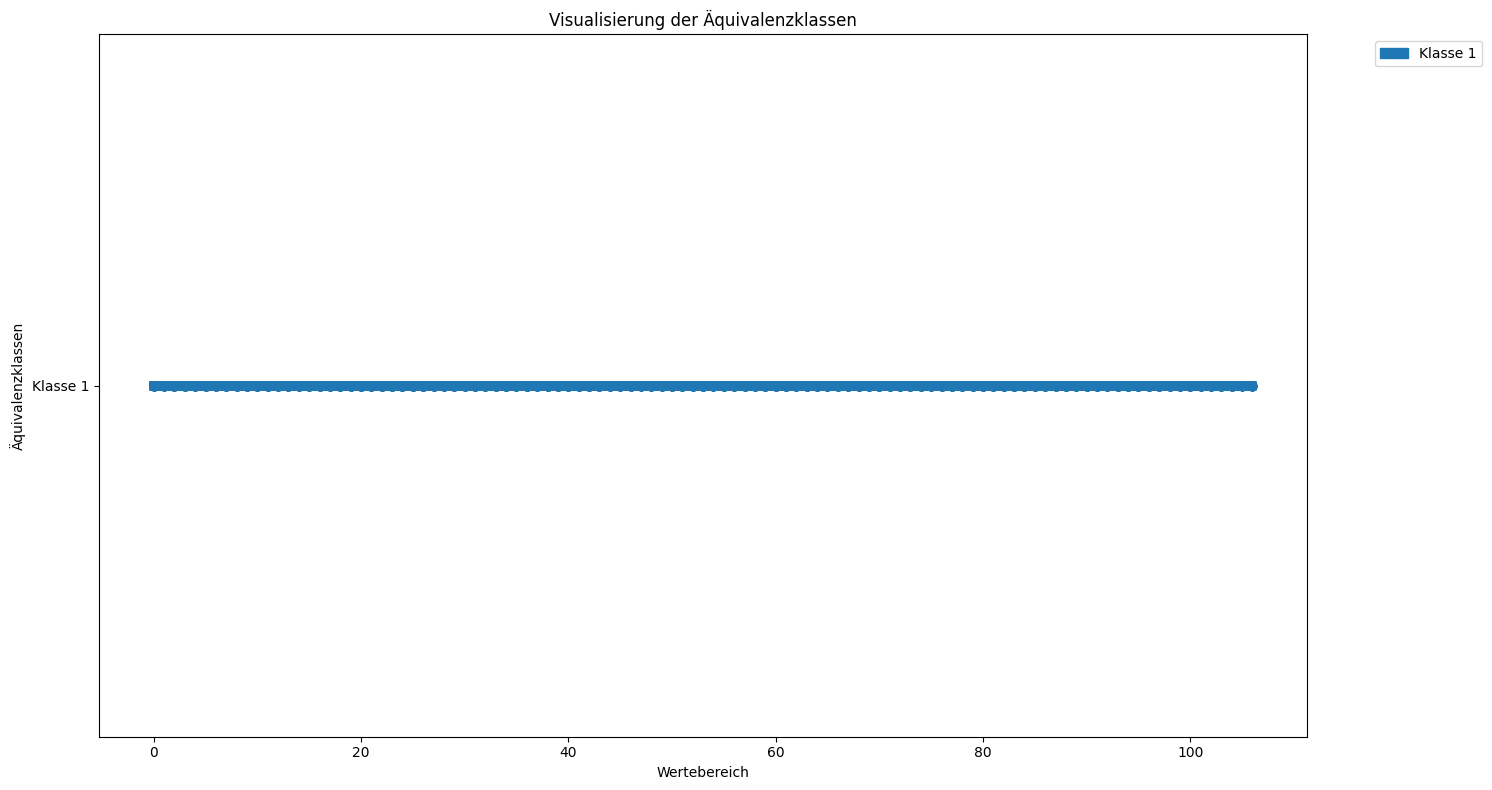

In [28]:
# Farben für verschiedene Äquivalenzklassen
farben = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(15, 8))

# Plot der Intervalle für jede Äquivalenzklasse
for i, klasse in enumerate(aequivalenzklassen):
    for interval in klasse:
        ax.plot([interval[0], interval[1]], [i, i], marker='o', linewidth=6, color=farben[i % len(farben)])

# Achsentitel und Beschriftungen
ax.set_yticks(range(len(aequivalenzklassen)))
ax.set_yticklabels([f'Klasse {i+1}' for i in range(len(aequivalenzklassen))])
ax.set_xlabel('Wertebereich')
ax.set_ylabel('Äquivalenzklassen')
ax.set_title('Visualisierung der Äquivalenzklassen')

# Legende hinzufügen
legenden_patches = [mpatches.Patch(color=farben[i % len(farben)], label=f'Klasse {i+1}') for i in range(len(aequivalenzklassen))]
ax.legend(handles=legenden_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()